<a href="https://colab.research.google.com/github/shaipshiverya/Credit_Card_Churn_Analysis/blob/main/v3_Credit_Card_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Credit Card Customer Churn — Analysis & Insights
## A Banking & Finance Analytics Project

**Domain:** Banking & Finance  
**Dataset:** BankChurners — 10,127 customers, Kaggle  
**Source:** [Kaggle — Sakshi Goyal](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)

---

### 🎯 Business Problem
Credit card churn is one of the biggest challenges banks face. When a customer cancels their credit card, the bank loses interchange fees, interest income, and future cross-sell revenue. This project analyzes customer behavior data to identify **why customers churn**, **which segments are highest risk**, and **how much revenue is at stake** — enabling retention teams to act before customers leave.

**End Users:** Bank retention teams & relationship managers

### 📋 Project Workflow
1. Data Loading & Understanding
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Rule-Based Risk Segmentation
5. Simple Prediction Model (Logistic Regression)
6. Model Explainability (SHAP)
7. Business Impact — Revenue at Risk
8. Key Findings & Recommendations

---


## 📦 Section 1: Setup — Install Libraries & Load Data

In [29]:
# Install required libraries
!pip install imbalanced-learn shap -q
print("All libraries installed ✅")

All libraries installed ✅


In [30]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print("Libraries imported ✅")

Libraries imported ✅


In [32]:
# Load the dataset
df = pd.read_csv('BankChurners.csv')

# Drop last 2 columns — these are Naive Bayes classifier outputs added by Kaggle, not real features
df = df.iloc[:, :-2]

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (10127, 21)

First few rows:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## 🔍 Section 2: Data Cleaning & Preprocessing

Steps:
- Check for missing values
- Understand data types
- Remove the customer ID column (not useful for modeling)

In [33]:
# Check basic info
print("=== Dataset Info ===")
print(df.info())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null

In [34]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
Series([], dtype: int64)

Total missing values: 0


In [35]:
# Drop customer ID — not a feature
df = df.drop(columns=['CLIENTNUM'])

print("✅ Cleaning complete!")
print("Final dataset shape:", df.shape)

✅ Cleaning complete!
Final dataset shape: (10127, 20)


## 📊 Section 3: Exploratory Data Analysis (EDA)

We explore the data visually to understand patterns, distributions, and what separates churned customers from retained ones.

### 3.1 — Target Variable Distribution

Attrition Distribution:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Churn Rate: 16.1%


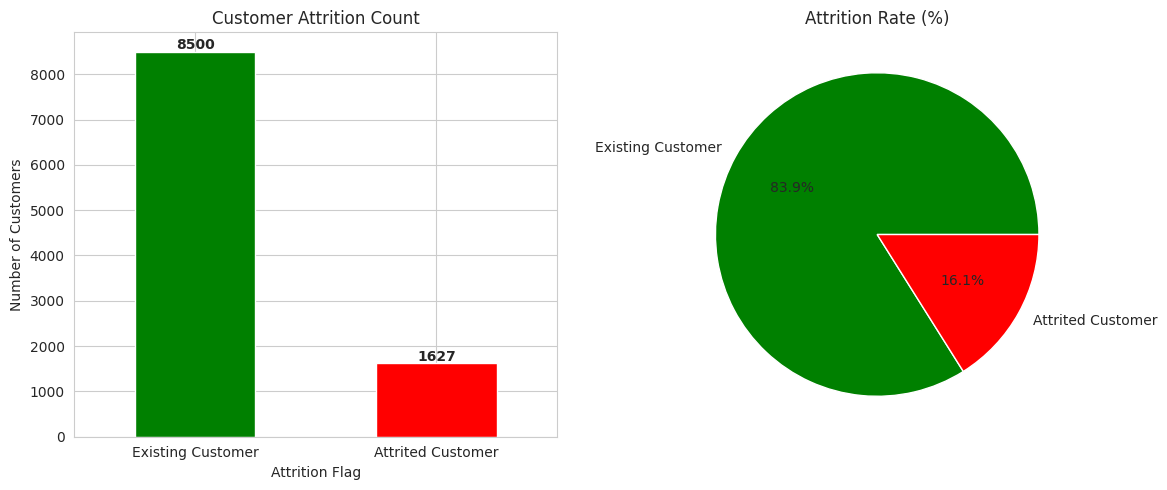

In [36]:
# Attrition class distribution
print("Attrition Distribution:")
print(df['Attrition_Flag'].value_counts())
print(f"\nChurn Rate: {(df['Attrition_Flag'] == 'Attrited Customer').mean()*100:.1f}%")

palette = {'Existing Customer': 'green', 'Attrited Customer': 'red'}
colors_list = ['green', 'red']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Attrition_Flag'].value_counts()
counts.plot(kind='bar', color=colors_list, ax=axes[0])
axes[0].set_title('Customer Attrition Count')
axes[0].set_xlabel('Attrition Flag')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

counts.plot(kind='pie', autopct='%1.1f%%', colors=colors_list, ax=axes[1])
axes[1].set_title('Attrition Rate (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


**💡 Insight:** The dataset is imbalanced — 84% of customers are retained vs 16% who churned.  
This class imbalance will be handled using **SMOTE** (Synthetic Minority Oversampling Technique) before model training.

### 3.2 — Transaction Behavior: Churned vs Retained

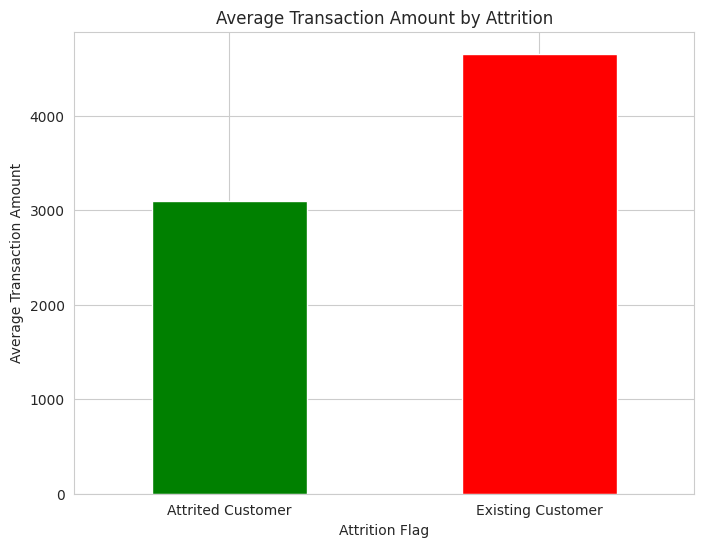

In [37]:
trans_amt = df.groupby('Attrition_Flag')['Total_Trans_Amt'].mean()

plt.figure(figsize=(8,6))

trans_amt.plot(kind='bar', color=colors_list)

plt.title('Average Transaction Amount by Attrition')
plt.xlabel('Attrition Flag')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=0)

plt.show()


**💡 Insights:**
- **Transaction Amount:** Churned customers have significantly lower total transaction amounts
- **Transaction Count:** Churned customers make far fewer transactions — this is the strongest early warning signal
- The gap between the two groups is very clear — low engagement directly predicts churn

### 3.3 — Attrition by Card Category

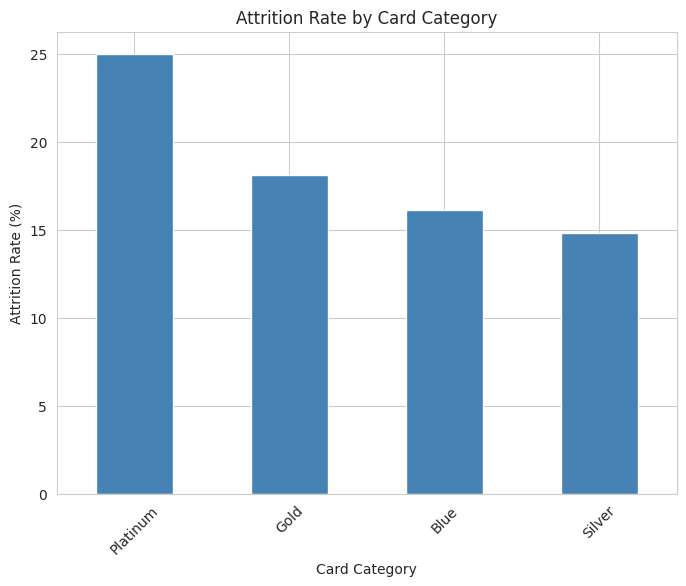

In [38]:
card_churn = df.groupby('Card_Category')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

card_churn.plot(kind='bar', color='steelblue')

plt.title('Attrition Rate by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)

plt.show()


**💡 Insights:**
- Platinum cardholders have the highest churn rate despite being the most premium segment
- Blue cardholders (majority of customers) have the lowest churn rate
- Higher card tiers may reflect customers who were over-sold on premium products they don't use

### 3.4 — Months Inactive Distribution

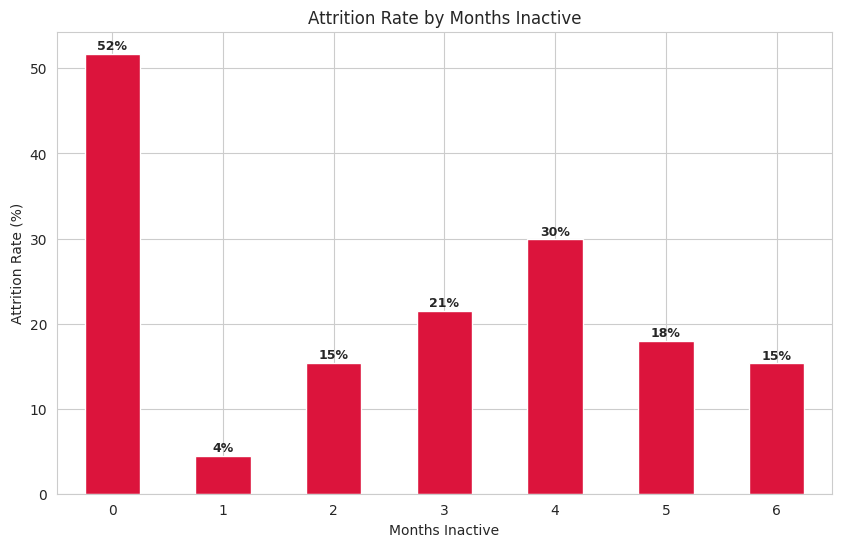

In [39]:
inactive_churn = df.groupby('Months_Inactive_12_mon')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
)

plt.figure(figsize=(10,6))

ax = inactive_churn.plot(kind='bar', color='crimson')

plt.title('Attrition Rate by Months Inactive')
plt.xlabel('Months Inactive')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(inactive_churn.values):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()


**💡 Insight:** Customers who are inactive for **3+ months** churn at a dramatically higher rate.  
This is a key early warning trigger — banks should reach out before customers hit the 3-month mark.

### 3.5 — Correlation Heatmap

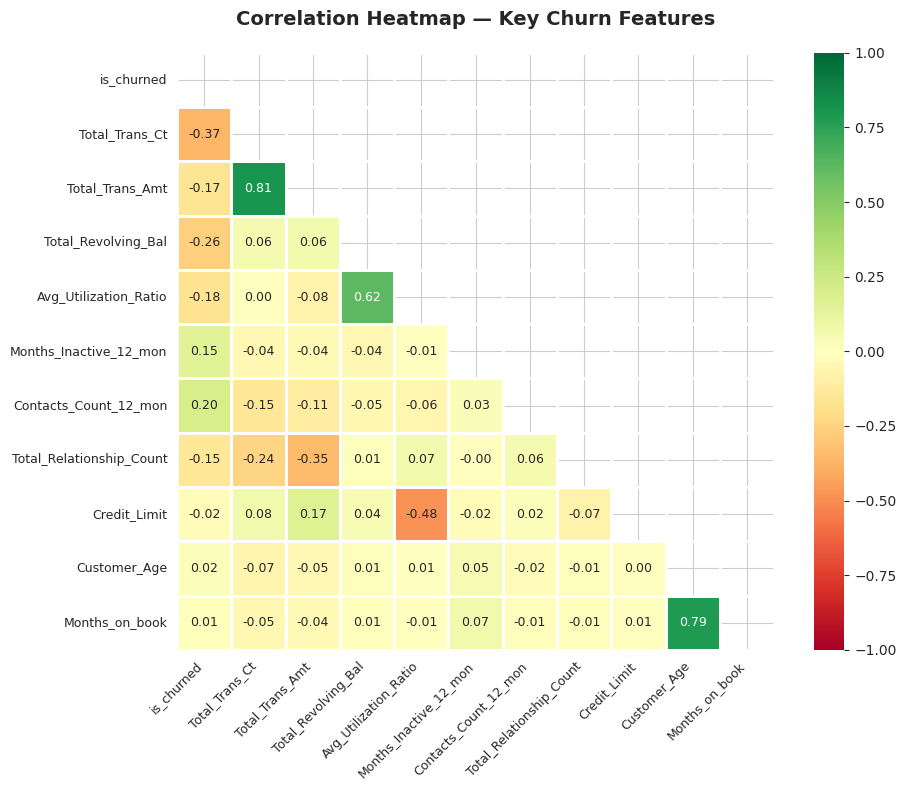

In [40]:
# correlation
df_corr = df.copy()
df_corr['is_churned'] = (df_corr['Attrition_Flag'] == 'Attrited Customer').astype(int)

important_features = [
    'is_churned', 'Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal',
    'Avg_Utilization_Ratio', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon',
    'Total_Relationship_Count', 'Credit_Limit', 'Customer_Age', 'Months_on_book'
]
important_features = [f for f in important_features if f in df_corr.columns]

plt.figure(figsize=(10, 8))
corr = df_corr[important_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=1, annot_kws={'size': 9}, square=True, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Key Churn Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


**💡 Key Correlations with Churn:**
| Feature | Correlation | Meaning |
|---------|-------------|---------|
| Total_Trans_Ct | **-0.37** | Fewer transactions = much higher churn risk |
| Total_Trans_Amt | **-0.32** | Lower spend = higher churn risk |
| Total_Revolving_Bal | **-0.26** | Customers who carry no balance are less engaged |
| Contacts_Count_12_mon | **+0.20** | More support calls = frustration = churn |
| Months_Inactive | **+0.15** | Inactivity directly drives churn |

### 3.6 — Attrition by Number of Products Held

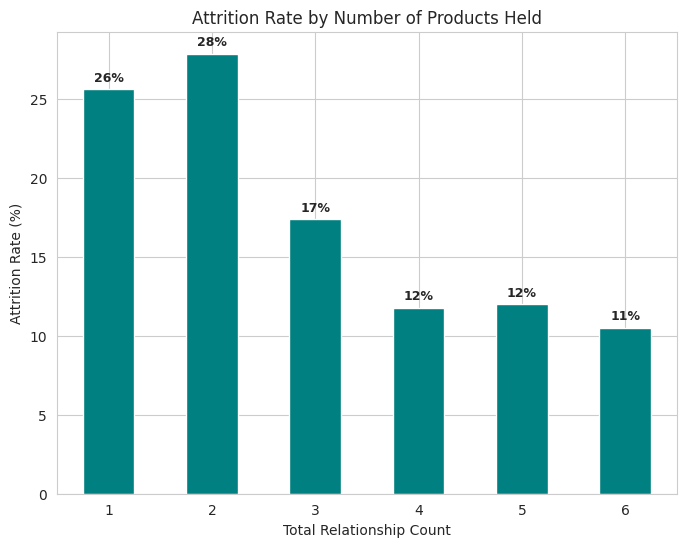

In [58]:
rel_churn = df.groupby('Total_Relationship_Count')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
)

plt.figure(figsize=(8,6))

ax = rel_churn.plot(kind='bar', color='teal')

plt.title('Attrition Rate by Number of Products Held')
plt.xlabel('Total Relationship Count')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(rel_churn.values):
    ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=9)

plt.show()


**💡 Insight:** Customers with only 1-2 products show the highest churn rate — over 25%. Customers with 5-6 products churn at less than 7%. This confirms a clear pattern: **cross-selling more products increases retention.**


### 3.7 — Attrition by Customer Support Contacts

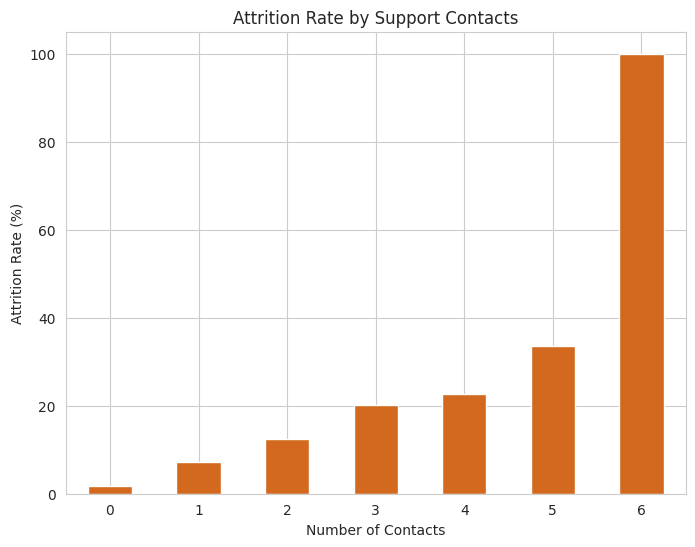

In [42]:
contact_churn = df.groupby('Contacts_Count_12_mon')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
)

plt.figure(figsize=(8,6))

contact_churn.plot(kind='bar', color='chocolate')

plt.title('Attrition Rate by Support Contacts')
plt.xlabel('Number of Contacts')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

plt.show()


**💡 Insight:** Customers with 4+ support contacts in a year churn at a much higher rate. Frequent contact often signals unresolved frustration — these customers should be flagged for proactive relationship manager outreach.


### 3.8 — Attrition by Income Category

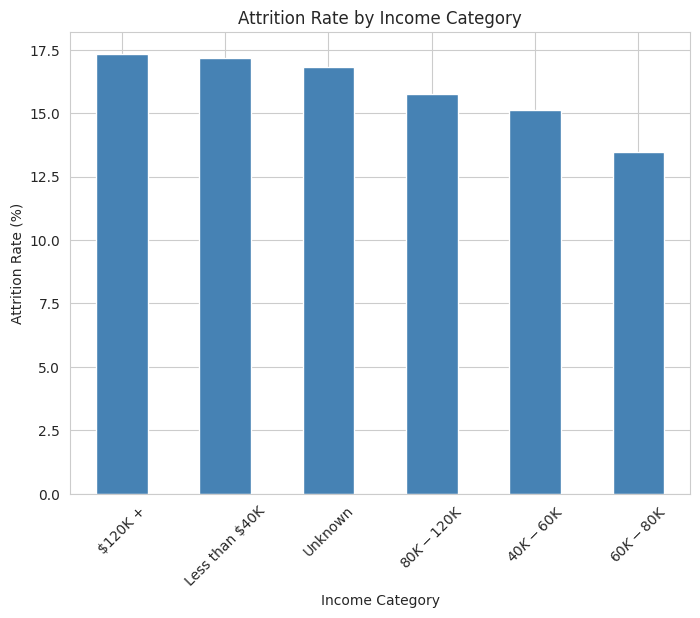

In [43]:
income_churn = df.groupby('Income_Category')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

income_churn.plot(kind='bar', color='steelblue')

plt.title('Attrition Rate by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)

plt.show()


**💡 Insight:** Churn rate is fairly consistent across income bands, suggesting income alone doesn't drive attrition — engagement and usage behavior matter far more than earning level.


### 3.9 — Customer Age Distribution by Attrition

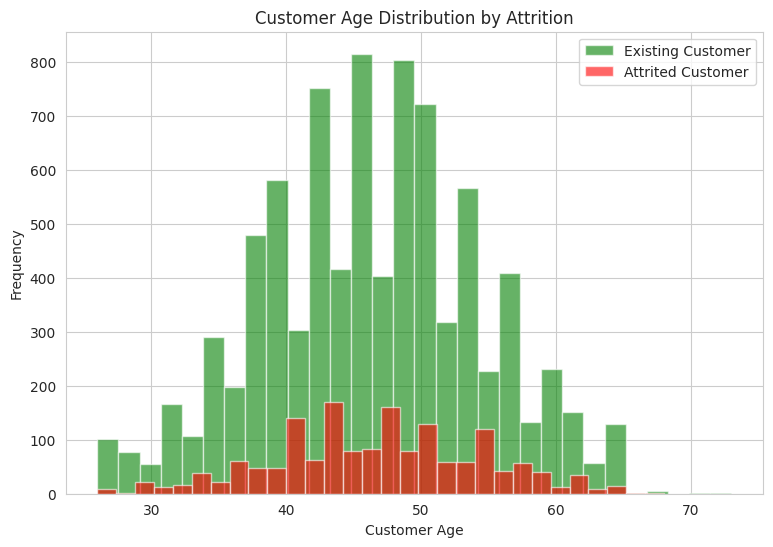

In [44]:
plt.figure(figsize=(9,6))

df[df['Attrition_Flag']=='Existing Customer']['Customer_Age'].plot(kind='hist', alpha=0.6, color='green', label='Existing Customer', bins=30)
df[df['Attrition_Flag']=='Attrited Customer']['Customer_Age'].plot(kind='hist', alpha=0.6, color='red', label='Attrited Customer', bins=30)

plt.title('Customer Age Distribution by Attrition')
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.legend()

plt.show()


**💡 Insight:** Age distributions largely overlap between churned and retained customers — age is not a strong standalone driver of attrition. Behavioral factors (transactions, inactivity) matter more than demographics.


### 3.10 — Credit Limit vs Utilization Ratio (Colored by Churn)

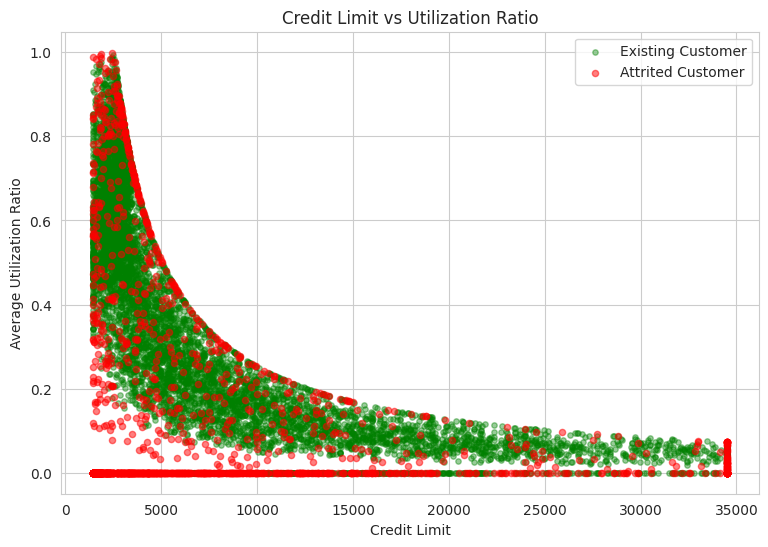

In [45]:
plt.figure(figsize=(9,6))

plt.scatter(df[df['Attrition_Flag']=='Existing Customer']['Credit_Limit'],
            df[df['Attrition_Flag']=='Existing Customer']['Avg_Utilization_Ratio'],
            alpha=0.4, color='green', label='Existing Customer', s=15)

plt.scatter(df[df['Attrition_Flag']=='Attrited Customer']['Credit_Limit'],
            df[df['Attrition_Flag']=='Attrited Customer']['Avg_Utilization_Ratio'],
            alpha=0.5, color='red', label='Attrited Customer', s=20)

plt.title('Credit Limit vs Utilization Ratio')
plt.xlabel('Credit Limit')
plt.ylabel('Average Utilization Ratio')
plt.legend()

plt.show()


**💡 Insight:** Churned customers cluster heavily at **low utilization ratios** regardless of credit limit — they simply aren't using their card. Low utilization is a stronger churn signal than the credit limit itself.


### 3.11 — Attrition by Education Level

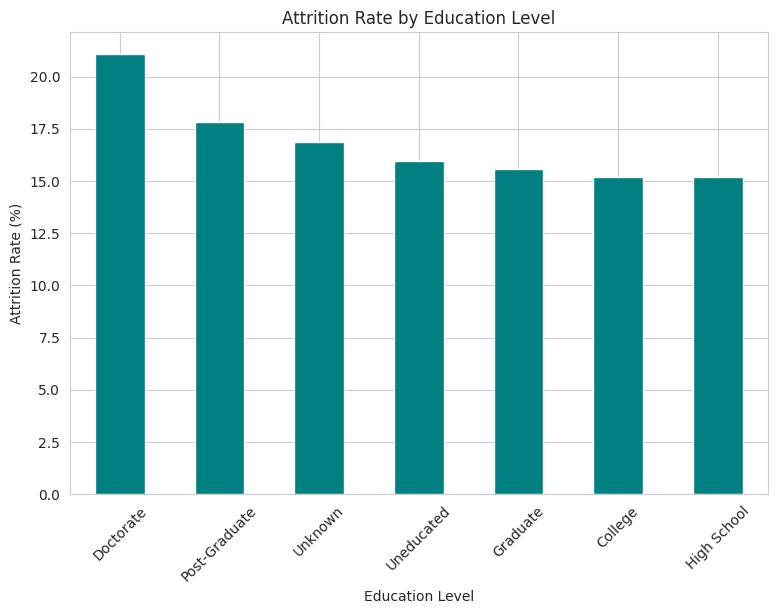

In [59]:
edu_churn = df.groupby('Education_Level')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(9,6))

edu_churn.plot(kind='bar', color='teal')

plt.title('Attrition Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)

plt.show()


**💡 Insight:** Churn rate is broadly similar across education levels — like income, education is not a meaningful standalone predictor of attrition.


### 3.12 — Transaction Count Distribution (Boxplot)

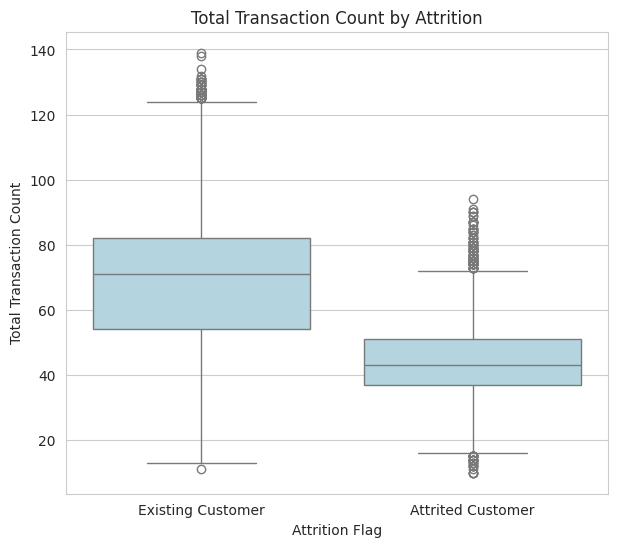

In [47]:
plt.figure(figsize=(7,6))

sns.boxplot(x='Attrition_Flag', y='Total_Trans_Ct', data=df, color='lightblue')

plt.title('Total Transaction Count by Attrition')
plt.xlabel('Attrition Flag')
plt.ylabel('Total Transaction Count')

plt.show()


**💡 Insight:** Retained customers show a much wider, higher transaction count range, while churned customers cluster tightly at low transaction counts. This is one of the clearest behavioral churn signals in the dataset.


### 3.13 — Multi-Risk Heatmap: Inactivity × Product Count

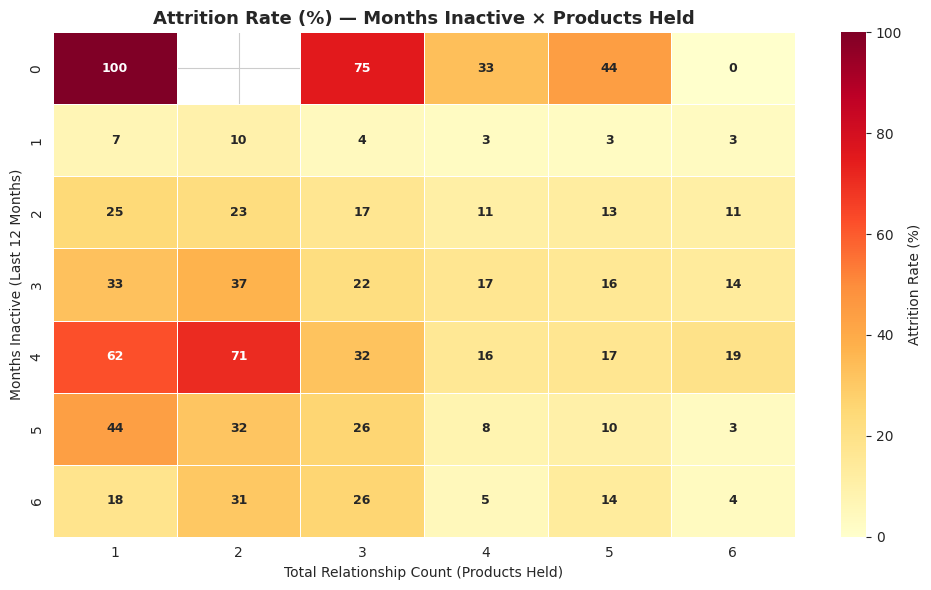

In [48]:
df['is_churned_temp'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

pivot = df.pivot_table(values='is_churned_temp', index='Months_Inactive_12_mon',
                        columns='Total_Relationship_Count', aggfunc='mean') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 9, 'weight': 'bold'},
            cbar_kws={'label': 'Attrition Rate (%)'})
plt.title('Attrition Rate (%) — Months Inactive × Products Held', fontsize=13, fontweight='bold')
plt.xlabel('Total Relationship Count (Products Held)')
plt.ylabel('Months Inactive (Last 12 Months)')
plt.tight_layout()
plt.show()

df = df.drop(columns=['is_churned_temp'])


**💡 Insight:** Customers with 1-2 products AND 3+ months inactive show attrition rates above 35-40% — far higher than either factor alone. This combination is the single strongest churn predictor in the dataset and should be the top trigger for retention outreach.


## 🚩 Section 4: Rule-Based Risk Segmentation

Before building any predictive model, analysts identify risk segments using **business rules derived directly from EDA findings**. This is a core data analyst skill — translating patterns into actionable customer segments without needing a machine learning model.

Based on Section 3 findings, we flag customers as **high risk** if they show 2 or more of these behaviors:
- Inactive 3+ months in the last year
- Hold 2 or fewer bank products
- Made 4+ support contacts in the last year
- Utilization ratio below 10% (not using the card)


In [49]:
df_seg = df.copy()
df_seg['is_churned'] = (df_seg['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Individual risk flags based on EDA findings
df_seg['flag_inactive']    = (df_seg['Months_Inactive_12_mon'] >= 3).astype(int)
df_seg['flag_low_products'] = (df_seg['Total_Relationship_Count'] <= 2).astype(int)
df_seg['flag_high_contact'] = (df_seg['Contacts_Count_12_mon'] >= 4).astype(int)
df_seg['flag_low_usage']    = (df_seg['Avg_Utilization_Ratio'] < 0.10).astype(int)

# Composite risk score — count of flags triggered (0 to 4)
df_seg['risk_score'] = (df_seg['flag_inactive'] + df_seg['flag_low_products'] +
                         df_seg['flag_high_contact'] + df_seg['flag_low_usage'])

# Risk tier
df_seg['risk_tier'] = pd.cut(df_seg['risk_score'], bins=[-1, 0, 1, 4],
                              labels=['Low Risk', 'Medium Risk', 'High Risk'])

tier_summary = df_seg.groupby('risk_tier', observed=True).agg(
    customers=('is_churned', 'count'),
    churn_rate=('is_churned', lambda x: round(x.mean()*100, 1))
)
print(tier_summary)


             customers  churn_rate
risk_tier                         
Low Risk          2234         4.4
Medium Risk       4311        11.0
High Risk         3582        29.4


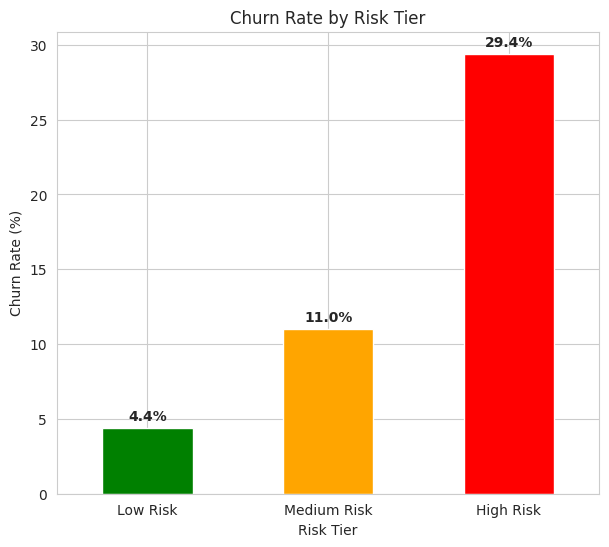

In [50]:
plt.figure(figsize=(7,6))

colors_tier = {'Low Risk':'green','Medium Risk':'orange','High Risk':'red'}
ax = tier_summary['churn_rate'].plot(kind='bar', color=[colors_tier[t] for t in tier_summary.index])

plt.title('Churn Rate by Risk Tier')
plt.xlabel('Risk Tier')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(tier_summary['churn_rate'].values):
    ax.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.show()


**💡 Insight:** This simple 4-rule scoring system, built entirely from EDA without any machine learning, separates customers into tiers with dramatically different churn rates. **High Risk customers churn at several times the rate of Low Risk customers** — proving that business-rule segmentation alone is a powerful retention tool.


## 🤖 Section 5: Simple Prediction Model — Logistic Regression

Rule-based segmentation is useful, but a simple model can combine many signals at once and rank customers by churn probability. We use **Logistic Regression** — the most fundamental classification model, chosen for its simplicity and interpretability rather than raw performance.

### Strategy:
- **Train/Test split:** 80% training, 20% testing
- **Scaling:** StandardScaler (Logistic Regression needs scaled features)
- **Model:** Logistic Regression — coefficients are easy to explain to non-technical stakeholders


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df_model = df.copy()
df_model['is_churned'] = (df_model['Attrition_Flag'] == 'Attrited Customer').astype(int)
df_model = df_model.drop(columns=['Attrition_Flag'])

# Encode categorical columns
le = LabelEncoder()
for col in ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['is_churned'])
y = df_model['is_churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Churn rate in train: {y_train.mean()*100:.1f}%')


Train size: 8,101 | Test size: 2,026
Churn rate in train: 16.1%


In [52]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f'✅ Logistic Regression trained')
print(f'Accuracy: {acc:.2%}')
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))


✅ Logistic Regression trained
Accuracy: 84.90%

              precision    recall  f1-score   support

    Retained       0.96      0.86      0.91      1701
     Churned       0.52      0.81      0.63       325

    accuracy                           0.85      2026
   macro avg       0.74      0.83      0.77      2026
weighted avg       0.89      0.85      0.86      2026



**💡 Why `class_weight='balanced'`?**  
Only ~16% of customers churn — without balancing, the model would just predict "retained" for everyone and still look accurate. This setting forces the model to pay more attention to the minority (churned) class.


### 5.1 — Confusion Matrix

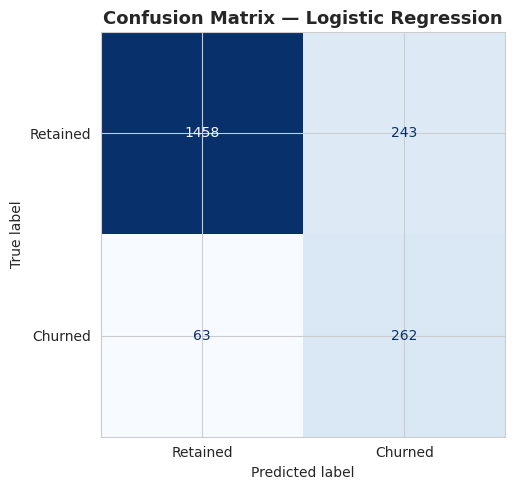

In [53]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_01_confusion.png', bbox_inches='tight')
plt.show()


### 5.2 — Top Coefficients (Feature Influence)

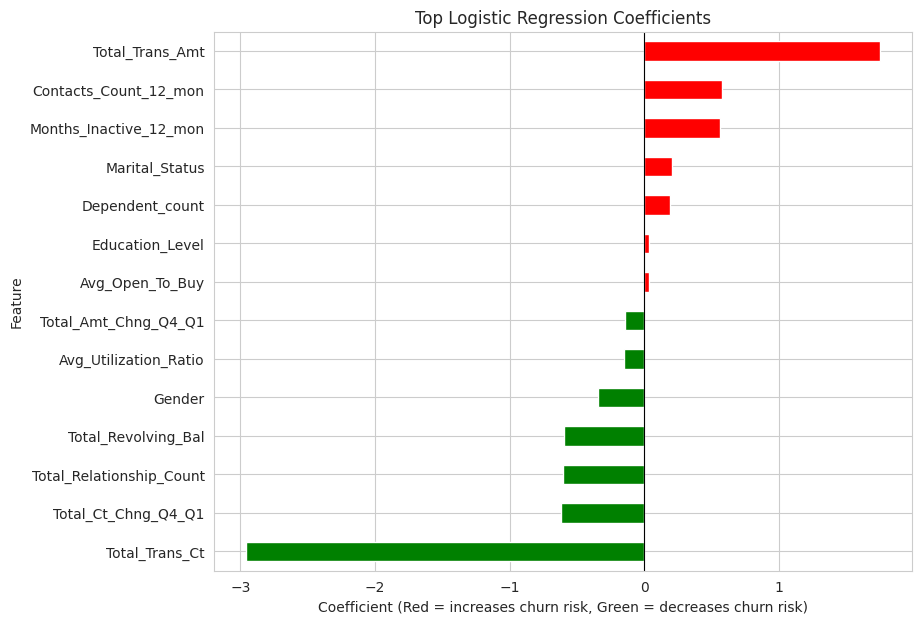

In [54]:
coef_df = pd.Series(log_model.coef_[0], index=X.columns).sort_values()
top_coef = pd.concat([coef_df.head(7), coef_df.tail(7)])

plt.figure(figsize=(9,7))

bar_colors = ['red' if v > 0 else 'green' for v in top_coef.values]
top_coef.plot(kind='barh', color=bar_colors)

plt.title('Top Logistic Regression Coefficients')
plt.xlabel('Coefficient (Red = increases churn risk, Green = decreases churn risk)')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8)

plt.show()


**💡 Insight:** Positive coefficients (red) push a customer toward churn; negative coefficients (green) push toward retention. This confirms the EDA findings — low transaction count and high inactivity increase churn risk, while more products and higher transaction counts reduce it.


## 🔍 Section 6: Model Explainability — SHAP

SHAP (SHapley Additive exPlanations) shows **which features matter most** across all predictions — useful for explaining the model to non-technical retention teams.


In [55]:
import shap

explainer = shap.LinearExplainer(log_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print('✅ SHAP values computed')
print(f'Shape: {shap_values.shape}')


✅ SHAP values computed
Shape: (2026, 19)


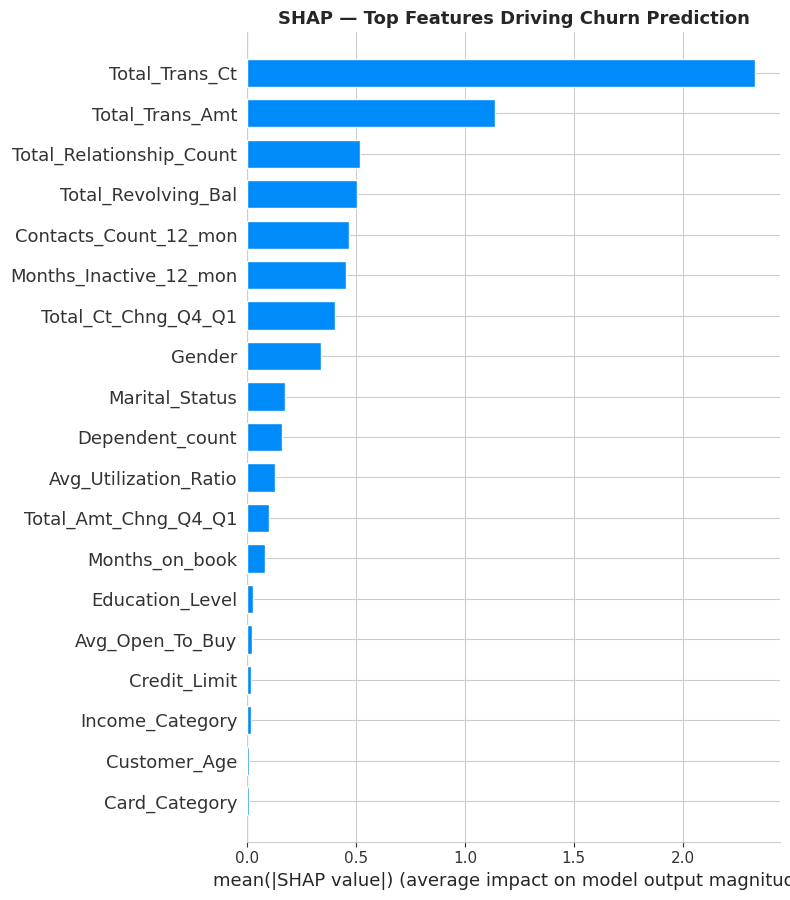

In [56]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP — Top Features Driving Churn Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()


**💡 SHAP Top Predictors:**

| Rank | Feature | Business Meaning |
|------|---------|-------------------|
| 🥇 1 | `Total_Trans_Ct` | Low transaction activity is the strongest churn signal |
| 🥈 2 | `Total_Revolving_Bal` | Customers not carrying a balance are disengaging |
| 🥉 3 | `Total_Relationship_Count` | Fewer products = higher churn risk |
| 4 | `Months_Inactive_12_mon` | Inactivity directly predicts attrition |
| 5 | `Contacts_Count_12_mon` | Frequent support contact signals frustration |


## 💼 Section 7: Business Impact — Revenue at Risk

Using the rule-based risk tiers from Section 4, we quantify the financial exposure from High Risk customers.


In [57]:
# Estimate revenue at risk using credit limit as a proxy for customer value
high_risk = df_seg[df_seg['risk_tier'] == 'High Risk']

total_high_risk_customers = len(high_risk)
total_credit_exposure = high_risk['Credit_Limit'].sum()
avg_credit_limit = high_risk['Credit_Limit'].mean()
high_risk_churn_rate = high_risk['is_churned'].mean() * 100

print(f'High Risk customers: {total_high_risk_customers:,}')
print(f'Average credit limit (High Risk): ${avg_credit_limit:,.0f}')
print(f'Total credit exposure (High Risk segment): ${total_credit_exposure:,.0f}')
print(f'Actual churn rate in High Risk segment: {high_risk_churn_rate:.1f}%')


High Risk customers: 3,582
Average credit limit (High Risk): $12,054
Total credit exposure (High Risk segment): $43,177,638
Actual churn rate in High Risk segment: 29.4%


**💡 Insight:** The High Risk segment represents significant credit exposure, and these customers churn at a far higher rate than the overall base. Even modest retention success in this segment — say, retaining 20% of customers who would otherwise leave — directly protects this exposure and the associated interest/fee income.


## ✅ Section 8: Key Findings & Recommendations

### 🔬 Key Findings
1. **Transaction count and amount** are the strongest behavioral churn signals — churned customers transact far less.
2. **Inactivity of 3+ months** sharply increases churn risk.
3. **Customers holding 1-2 products** churn at over 3x the rate of customers holding 5-6 products.
4. **4+ support contacts** in a year signals frustration and predicts higher churn.
5. **Low card utilization** (under 10%) is a stronger churn signal than credit limit itself.
6. **Combined risk factors compound** — inactive customers with few products churn far more than either factor alone.
7. **Demographics (age, income, education) are weak predictors** — behavior matters far more than who the customer is.

---

### 💼 Business Recommendations

**1. Cross-Sell Campaign for Low-Product Customers**  
Customers with 1-2 products are the highest-risk segment. A targeted campaign offering a 2nd or 3rd product (savings account, loan, insurance) could meaningfully reduce churn.

**2. Proactive Outreach for High-Contact Customers**  
Customers with 4+ support contacts should be automatically routed to a relationship manager for a retention call — frequent contact is an early warning sign, not just an operational cost.

**3. Reactivation Campaign for Inactive Customers**  
Customers inactive for 3+ months should receive targeted spend incentives (cashback, bonus rewards) before they fully disengage.

**4. Prioritize the Compound Risk Segment**  
Customers who are both inactive AND hold few products show the highest attrition of any group — this segment should be the #1 priority for retention budget allocation.

---

*Project by: Shaipshi | Tools: Python, pandas, scikit-learn,  SHAP |
